# 05 — Results & Visualisation

The key finding: **does lagged sentiment predict abnormal returns?**

Also produces the final figures for LinkedIn/TikTok.

**Prerequisite:** Run notebooks 01–04 first.

In [1]:
import sys
sys.path.insert(0, '../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr

from utils import TICKERS, EVENT_DATES

car_df  = pd.read_csv('../data/processed/car_results.csv', parse_dates=['date'])
scores  = pd.read_csv('../data/processed/sentiment_scores.csv', parse_dates=['date'])
scores['date'] = pd.to_datetime(scores['date'])
car_df['date'] = pd.to_datetime(car_df['date'])

/Users/jamilasabazova/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/jamilasabazova/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


## 5a. Merge sentiment + abnormal returns

For the key test we align daily sentiment with daily abnormal returns and test whether lag-1 and lag-2 sentiment predicts next-day AR.

In [2]:
# Merge AR with sentiment on date × event
merged = car_df.merge(
    scores[['date', 'event', 'vader_weighted', 'finbert_weighted']],
    on=['date', 'event'],
    how='left'
)
merged = merged.sort_values(['ticker', 'event', 'day'])
print(merged.head(10))

      ticker              event  event_date       date  day        ar  \
56   1913.HK       full_trailer  2026-02-01 2026-01-29   -2 -0.002384   
57   1913.HK       full_trailer  2026-02-01 2026-01-30   -1  0.010263   
58   1913.HK       full_trailer  2026-02-01 2026-02-02    0  0.013260   
59   1913.HK       full_trailer  2026-02-01 2026-02-03    1 -0.011159   
60   1913.HK       full_trailer  2026-02-01 2026-02-04    2  0.012130   
61   1913.HK       full_trailer  2026-02-01 2026-02-05    3  0.024727   
62   1913.HK       full_trailer  2026-02-01 2026-02-06    4  0.000760   
63   1913.HK       full_trailer  2026-02-01 2026-02-09    5  0.007365   
308  1913.HK  musical_extension  2026-03-13 2026-03-11   -2  0.019833   
309  1913.HK  musical_extension  2026-03-13 2026-03-12   -1  0.005597   

          car      beta     alpha  vader_weighted  finbert_weighted  
56  -0.002384  0.638562 -0.001841        0.981900               NaN  
57   0.007879  0.638562 -0.001841             NaN       

## 5b. Lag correlation — sentiment → abnormal return

Test lags 0, 1, 2 for both VADER and FinBERT vs AR.

In [3]:
results = []

for ticker in TICKERS:
    for model in ['vader_weighted', 'finbert_weighted']:
        for lag in [0, 1, 2]:
            sub = merged[merged['ticker'] == ticker].copy()

            # Create lagged sentiment within each event
            sub['lagged_sentiment'] = sub.groupby('event')[model].shift(lag)
            aligned = sub[['ar', 'lagged_sentiment']].dropna()

            if len(aligned) < 5:
                continue

            r_p, p_p = pearsonr(aligned['lagged_sentiment'], aligned['ar'])
            r_s, p_s = spearmanr(aligned['lagged_sentiment'], aligned['ar'])

            results.append({
                'ticker': ticker,
                'model':  model.replace('_weighted','').upper(),
                'lag':    lag,
                'pearson_r': r_p,
                'pearson_p': p_p,
                'spearman_r': r_s,
                'spearman_p': p_s,
                'n': len(aligned),
            })

lag_df = pd.DataFrame(results)
print(lag_df.sort_values('pearson_r', ascending=False).head(20).to_string(index=False))

 ticker model  lag  pearson_r  pearson_p  spearman_r  spearman_p  n
 RMS.PA VADER    0   0.335249   0.042523    0.394263    0.015752 37
  MC.PA VADER    1   0.330970   0.048644    0.153153    0.372518 36
  MC.PA VADER    0   0.319301   0.054063    0.236131    0.159422 37
     EL VADER    2   0.319089   0.075062    0.204545    0.261449 32
1913.HK VADER    1   0.188705   0.270370    0.274646    0.105004 36
   CPRI VADER    1   0.161819   0.331739    0.006894    0.967236 38
    TPR VADER    0   0.124563   0.456201    0.041252    0.805757 38
 KER.PA VADER    0   0.082049   0.629257    0.026079    0.878231 37
1913.HK VADER    0   0.079291   0.640866    0.084874    0.617460 37
 KER.PA VADER    2   0.073756   0.698504    0.280534    0.133201 30
    TPR VADER    1   0.040038   0.811366    0.026589    0.874094 38
1913.HK VADER    2   0.029443   0.877256   -0.100779    0.596192 30
 RMS.PA VADER    1   0.024037   0.889328   -0.052252    0.762152 36
     EL VADER    0  -0.047553   0.776792    0.00

## 5c. Lag correlation heatmap

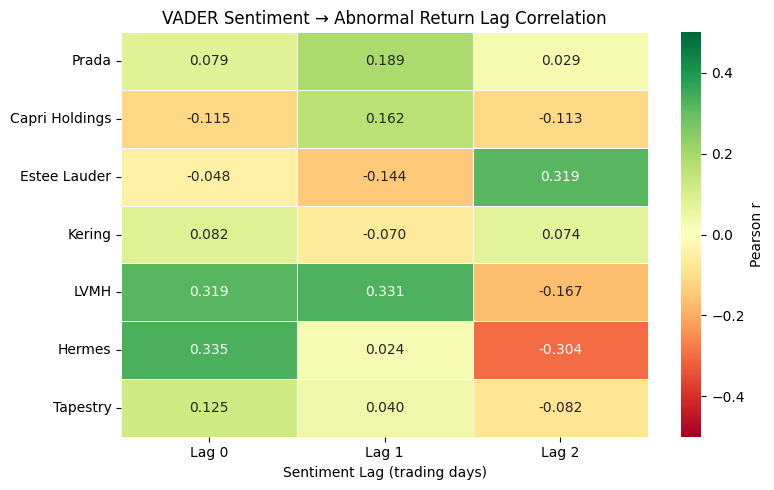

/Users/jamilasabazova/opt/anaconda3/lib/python3.9/site-packages/seaborn/matrix.py:309: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set(xlim=(0, self.data.shape[1]), ylim=(0, self.data.shape[0]))
/Users/jamilasabazova/opt/anaconda3/lib/python3.9/site-packages/seaborn/matrix.py:309: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set(xlim=(0, self.data.shape[1]), ylim=(0, self.data.shape[0]))


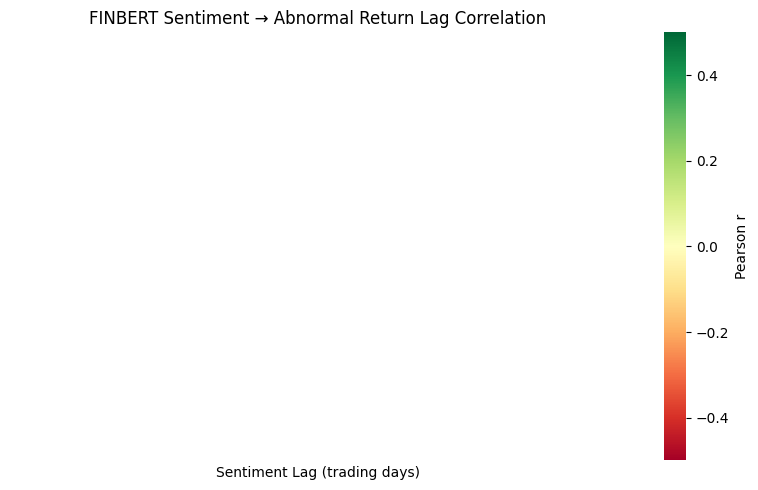

In [4]:
for model in ['VADER', 'FINBERT']:
    sub = lag_df[lag_df['model'] == model]
    pivot = sub.pivot(index='ticker', columns='lag', values='pearson_r')
    pivot.index = [TICKERS.get(t, t) for t in pivot.index]
    pivot.columns = [f'Lag {l}' for l in pivot.columns]

    fig, ax = plt.subplots(figsize=(8, 5))
    sns.heatmap(pivot, annot=True, fmt='.3f', cmap='RdYlGn', center=0,
                linewidths=0.5, ax=ax, vmin=-0.5, vmax=0.5,
                cbar_kws={'label': 'Pearson r'})
    ax.set_title(f'{model} Sentiment → Abnormal Return Lag Correlation')
    ax.set_xlabel('Sentiment Lag (trading days)')
    plt.tight_layout()
    plt.savefig(f'../results/figures/lag_correlation_{model.lower()}.png', dpi=150, bbox_inches='tight')
    plt.show()

lag_df.to_csv('../results/tables/lag_correlation.csv', index=False)

## 5d. Key finding summary

Narrative output for the LinkedIn article and TikTok results video.

In [5]:
car_summary = pd.read_csv('../data/processed/car_summary.csv')
car_summary['ticker_name'] = car_summary['ticker'].map(TICKERS)

sig = car_summary[car_summary['p_value'] < 0.05]
best = car_summary.loc[car_summary['total_car'].abs().idxmax()]
best_lag = lag_df.loc[lag_df['pearson_r'].abs().idxmax()]

print('═' * 60)
print('KEY FINDINGS')
print('═' * 60)

if len(sig) > 0:
    print(f'\n{len(sig)} statistically significant CAR results (p < 0.05):')
    for _, row in sig.iterrows():
        print(f'  {row["ticker_name"]} | {row["event"]} | CAR={row["total_car"]*100:.2f}% | p={row["p_value"]:.3f}')
else:
    print('\nNo statistically significant CARs (null hypothesis not rejected)')
    print('→ Cultural sentiment does not produce measurable equity price effects in these windows')

print(f'\nLargest absolute CAR: {best["ticker_name"]} at {best["event"]} = {best["total_car"]*100:.2f}%')
print(f'\nStrongest sentiment-return correlation:')
print(f'  {best_lag["ticker"]} | {best_lag["model"]} lag={best_lag["lag"]} | Pearson r={best_lag["pearson_r"]:.3f} p={best_lag["pearson_p"]:.3f}')
print('═' * 60)

════════════════════════════════════════════════════════════
KEY FINDINGS
════════════════════════════════════════════════════════════

3 statistically significant CAR results (p < 0.05):
  LVMH | musical_previews | CAR=5.47% | p=0.038
  Hermes | musical_previews | CAR=5.13% | p=0.004
  Tapestry | musical_opening | CAR=-8.74% | p=0.013

Largest absolute CAR: Capri Holdings at musical_previews = -75.97%

Strongest sentiment-return correlation:
  RMS.PA | VADER lag=0 | Pearson r=0.335 p=0.043
════════════════════════════════════════════════════════════


## 5e. Portfolio figure for LinkedIn / TikTok

Single clean chart: CPRI vs TPR CAR paths across the four events. 
This is the most compelling visual comparison (Versace cameo vs no association).

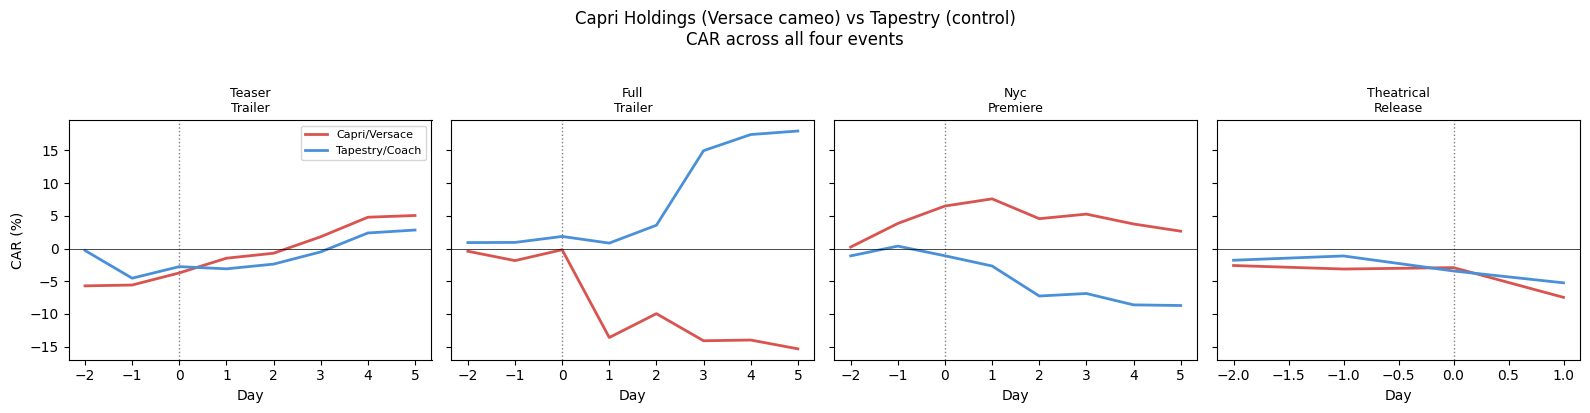

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)

for ax, event in zip(axes, EVENT_DATES):
    for ticker, color, label in [('CPRI','#D9534F','Capri/Versace'), ('TPR','#4A90D9','Tapestry/Coach')]:
        t_df = car_df[(car_df['ticker']==ticker) & (car_df['event']==event)].sort_values('day')
        if not t_df.empty:
            ax.plot(t_df['day'], t_df['car']*100, label=label, color=color, linewidth=2)
    ax.axvline(0, color='gray', linestyle=':', linewidth=1)
    ax.axhline(0, color='black', linewidth=0.5)
    ax.set_title(event.replace('_','\n').title(), fontsize=9)
    ax.set_xlabel('Day')

axes[0].set_ylabel('CAR (%)')
axes[0].legend(fontsize=8)
plt.suptitle('Capri Holdings (Versace cameo) vs Tapestry (control)\nCAR across all four events', y=1.02)
plt.tight_layout()
plt.savefig('../results/figures/cpri_vs_tpr.png', dpi=150, bbox_inches='tight')
plt.show()